<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [1 - Data Importing and Exploration](#1---data-importing-and-exploration)
    - 1a) Importing
    - 1b) Dataset Dimensions
    - 1c) Missing Values
    - 1d) Descriptive Statistics
    - 1e) Visualizations
    - 1f) Discussion
- [2 - Data Preparation](#2---data-preparation)
    - 2a) Scaling
- [3 - Identify Potential Outliers](#3---identify-potential-outliers)
    - 3a) Create IsolationForest
    - 3b) Establish IsolationForest Anomaly Threshold
    - 3c) Anomaly Histogram
    - 3d) Plot Outlier/Non-Outlier
    - 3e) Total Outliers
    - 3f) Extract Outlier Indicies
    - 3g) Discussion
- [4 - K-Means Clustering](#4---k-means-clustering)
    - 4a) Identify Optimal Clusters
    - 4b) Visualize Optimization Methods
    - 4c) Discussion
    - 4d) Train Optimized K-Means
- [5 - Gaussian Mixture Model](#5---gaussian-mixture-model)
    - 5a) Identify Optimal Clusters
    - 5b) Visualize AIC/BIC
    - 5c) Discussion
    - 5d) Train Optimized Gaussian
- [6 - DBSCAN](#6---dbscan)
    - 6a) Optimize min_samples
    - 6b) Optimize eps
    - 6c) Train Optimized DBSCAN
    - 6d) Total Outliers
    - 6e) Visualize Clusters and Outliers
    - 6f) Discussion
    - 6g) Make Copy and Remove Outliers
- [7 - Model Evaluation and Selection](#7---model-evaluation-and-selection)
    - 7a) Visualize 3 Model Clustering
    - 7b) Discussion of Clustering
    - 7c) Silhouette Scores and Davies-Bouldin Scores
    - 7d) Discussion of Scores

</div>

##### **IMPORTANT**

- Hyperlinks may not work, please use dropdowns if it helps navigability

---

##### **ORIENTATION**

- This follows COMP4432's week 9-10 assignment

---

##### **SUMMARY**

- In-Progress

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
# Arrays and matricies
import numpy as np

# Databasing
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and CV
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV

# Machine Learning Models
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

# Encoders/Scalers/Transformers
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples

# Ignore warnings because no...
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 1 - Data Importing and Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

### 1a) Importing

In [2]:
# Read in the specific dataset for clustering assignment
df = pd.read_csv('Assignment5_Data.csv')
df.head()

,x1,x2
0,-2.505828,4.231421
1,-2.015031,2.577902
2,-0.778732,3.736001
3,-1.525042,2.950457
4,-0.619687,2.703252


---

### 1b) Dataset Dimensions

In [8]:
# Display dataset dimensions
print(f'\033[35mRows:\033[0m\t{df.shape[0]}'
      f'\n\033[35mCols:\033[0m\t{df.shape[1]}')

Rows:	500
Cols:	2


---

### 1c) Missing Values

In [9]:
# Display total nulls in each col
df.isna().sum()

x1    0
x2    0
dtype: int64

---

### 1d) Descriptive Statistics

In [12]:
# Display dataset description
df.describe()

,x1,x2
count,500.000000,500.000000
mean,2.319361,4.906028
std,3.520610,1.495069
min,-3.564887,0.166537
25%,-0.421139,3.797372
50%,1.086455,5.381471
75%,5.288798,5.957691
max,10.717959,8.670240


---

### 1e) Visualizations

##### 1ei) Simple Plot

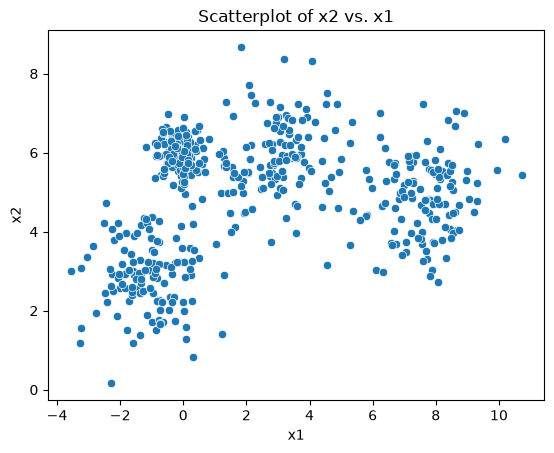

In [20]:
# Show the 500 points on the plot
plt.title('Scatterplot of x2 vs. x1')
sns.scatterplot(df, x=df['x1'], y=df['x2'])
plt.show()

##### 1eii) Density Plot

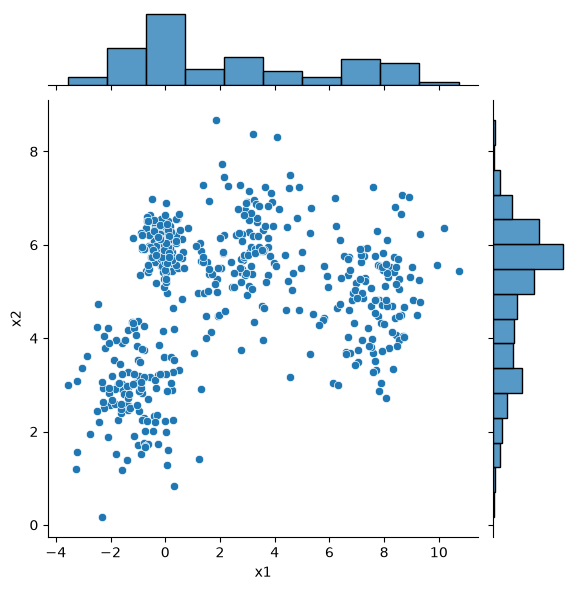

In [25]:
# Show the scatter and density plot
sns.jointplot(df, x=df['x1'], y=df['x2'])

---

### 1f) Discussion

From initial dataset exploration, the dataset is very simple and straightforward with 500 points spanning a neat 2D plane.  There appears to be some potential issues where the `x1` feature involves negative values.  Otherwise, from a strictly visual aspect with respect to clustering algorithms, there appears to be 4 clusters.  One of which is tightly clustered in the top left corner and the other three more diffused and overlapping with neighboring clusters.  In other words, the density of one cluster is high whereas the other 3 have lower densities.  

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 2 - Data Preparation

- [Back to Table of Contents](#table-of-contents)

</div>

### 2a) Scaling

In [32]:
# Scale both 'x1' and 'x2' for consistency in the 2D plane
df_scaled = StandardScaler().fit_transform(df)

# Send scaled data into a pandas dataframe
df_scaled = pd.DataFrame(df_scaled, columns=['x1', 'x2'])

# Observe descriptive statistics
df_scaled.describe()

,x1,x2
count,5.000000e+02,5.000000e+02
mean,-8.526513e-17,-3.979039e-16
std,1.001002e+00,1.001002e+00
min,-1.673046e+00,-3.173256e+00
25%,-7.791957e-01,-7.422841e-01
50%,-3.505475e-01,3.183255e-01
75%,8.442889e-01,7.041251e-01
max,2.387942e+00,2.520272e+00


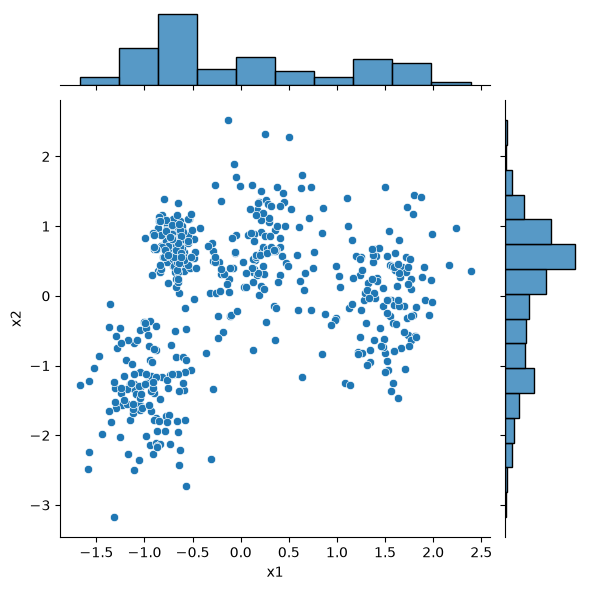

In [33]:
# Re-observe the density and scatterplot of the scaled data
sns.jointplot(df_scaled, x=df_scaled['x1'], y=df_scaled['x2'])

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 3 - Identify Potential Outliers

- [Back to Table of Contents](#table-of-contents)

</div>

### 3a) Create IsolationForest

---

### 3b) Establish IsolationForest Anomaly Threshold

---

### 3c) Anomaly Histogram

---

### 3d) Plot Outlier/Non-Outlier

---

### 3e) Total Outliers

---

### 3f) Extract Outlier Indicies

---

### 3g) Discussion

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 4 - K-Means Clustering

- [Back to Table of Contents](#table-of-contents)

</div>

### 4a) Identify Optimal Clusters

##### 4ai) Elbow Method

##### 4aii) Silhouette Score

##### 4aiii) Davies-Bouldin Score

---

### 4b) Visualize Optimization Methods

---

### 4c) Discussion

---

### 4d) Train Optimized K-Means

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 5 - Gaussian Mixture Model

- [Back to Table of Contents](#table-of-contents)

</div>

### 5a) Identify Optimal Clusters

---

### 5b) Visualize AIC/BIC

---

### 5c) Discussion

---

### 5d) Train Optimized Gaussian

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 6 - DBSCAN

- [Back to Table of Contents](#table-of-contents)

</div>

### 6a) Optimize `min_samples`

---

### 6b) Optimize `eps`

---

### 6c) Train Optimized DBSCAN

---

### 6d) Total Outliers

---

### 6e) Visualize Clusters and Outliers

---

### 6f) Discussion

---

### 6g) Make Copy and Remove Outliers

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 7 - Model Evaluation and Selection

- [Back to Table of Contents](#table-of-contents)

</div>

### 7a) Visualize 3 Model Clustering

---

### 7b) Discussion of Clustering

---

### 7c) Silhouette Scores and Davies-Bouldin Scores

---

### 7d) Discussion of Scores